In [1]:
!pip install scikit-learn xgboost

In [2]:
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from xgboost import XGBClassifier

random_seed = 2026

### The Plan
- Split trainval and test grouped by subject_ID (to prevent data leakage); stratify mind wandering
- KFold cross validation using trainval during hyperparameter gridsearch (I will try to prevent data leakage here as well); stratify mind wandering

## Load Data

In [3]:
# Load data
path = "data/preprocessed/data_2000.pkl"
data = pd.read_pickle(path).reset_index(drop=True)
display(data.head())

# Split data
groups = data["subject"]
X = data[["delta", "theta", "alpha", "beta", "gamma"]].astype(float)
y = data["is_mw"].astype(int)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_seed)

,subject,delta,theta,alpha,beta,gamma,is_mw
0,s10014,2.067734,0.329929,-0.720959,0.082369,-0.014123,0.0
1,s10014,2.46203,-0.286958,-0.132412,0.76453,0.564647,0.0
2,s10014,2.818473,-0.542748,-0.167326,0.725931,3.184791,0.0
3,s10014,0.453536,-0.747927,-0.457102,0.655211,4.901104,0.0
4,s10014,-0.030412,-0.327316,-0.753801,-0.104819,0.806283,0.0


### Plot data

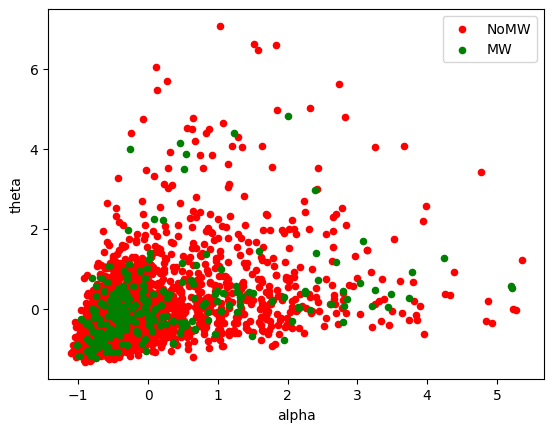

In [ ]:
ax = data[data.is_mw == False].plot.scatter(x="alpha",y="theta", color="red", label="NoMW")
data[data.is_mw == True].plot.scatter(x="alpha",y="theta", color="green", label="MW", ax=ax)
ax.legend()

# Problematic!

## Training
### Logistic Regression

In [21]:
def train_logistic_regression(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_seed)

    lr = LogisticRegression(random_state=random_seed)
    clf = GridSearchCV(lr, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y,groups=groups)
    
    return clf

### SVM with radial basis function

In [ ]:
def train_svc(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_seed)

    svc = SVC(random_state=random_seed)
    clf = GridSearchCV(svc, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y,groups=groups)
    
    return clf

### XGBoost

In [45]:
def train_xgboost(X, y, groups, parameters):
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=random_seed)

    xgb = XGBClassifier(random_state=random_seed, eval_metric="auc")
    clf = GridSearchCV(xgb, parameters, cv=cv, scoring="roc_auc") 

    clf.fit(X,y,groups=groups)
    
    return clf

### Training

In [ ]:
lr_params = { # Why these?
    'C': [1, 10, 100], 
    'class_weight': ["balanced"],
    'solver': ["lbfgs"],
    'max_iter': [100, 500],
    'warm_start': [True, False]
}

svm_params = { # Why these?
    'C': [1, 10, 100],
    'gamma': ["auto","scale", 0.01, 0.1]
}

xgb_params = { # Why these?
    'learning_rate': [0.001, 0.01, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, 25],
    'reg_alpha': [1, 3, 5, 10]
}

In [ ]:
X = X[""]
for fold, (train_idxs, test_idxs) in enumerate(cv.split(X, y, groups)):
    X_trainval, y_trainval = X.iloc[train_idxs].reset_index(drop=True), y[train_idxs].reset_index(drop=True)
    X_test, y_test = X.iloc[test_idxs].reset_index(drop=True), y[test_idxs].reset_index(drop=True)
    groups_train = groups[train_idxs]
    groups_test = groups[test_idxs]

    print(f"Fold {fold}")
    # best_logreg_clf = train_logistic_regression(X_trainval, y_trainval, groups_train, parameters=lr_params)
    # perf_auc = roc_auc_score(y_test, best_logreg_clf.predict_proba(X_test)[:,1],multi_class='ovo')
    # print(f"ROC-AUC (LogisticRegression({best_logreg_clf.best_params_})): {perf_auc}")

    # best_svm_clf = train_svc(X_trainval, y_trainval, groups_train, parameters=svm_params)
    # perf_auc = roc_auc_score(y_test, best_svm_clf.predict(X_test),multi_class='ovo')
    # print(f"ROC-AUC (SVC({best_svm_clf.best_params_})): {perf_auc}")

    best_xgb_clf = train_xgboost(X_trainval, y_trainval, groups_train, parameters=xgb_params)
    perf_auc = roc_auc_score(y_test, best_xgb_clf.predict(X_test),multi_class='ovo')
    print(f"ROC-AUC (XGBoost({best_xgb_clf.best_params_})): {perf_auc}")
    # print()
    # print("Fold :", fold)
    # print("TRAIN POSITIVE RATIO:", y[train_idxs].mean())
    # print("TEST POSITIVE RATIO :", y[test_idxs].mean())
    # print(f"TRAIN PERCENTAGE    : {len(train_idxs) / len(X) * 100:.4}%")
    # print("TRAIN GROUPS        :", set(groups[train_idxs]))
    # print("TEST GROUPS         :", set(groups[test_idxs]))

# Also: do I need to specify "ROC-AUC" for each individual model instantiation as well (on top of the CV?)

Fold 0
ROC-AUC (XGBoost({'learning_rate': 0.001, 'max_depth': 25, 'n_estimators': 200, 'reg_alpha': 3})): 0.5
Fold 1
ROC-AUC (XGBoost({'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1})): 0.48635235732009924
Fold 2
ROC-AUC (XGBoost({'learning_rate': 0.001, 'max_depth': 10, 'n_estimators': 100, 'reg_alpha': 5})): 0.5
Fold 3
ROC-AUC (XGBoost({'learning_rate': 0.001, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 1})): 0.5
Fold 4
ROC-AUC (XGBoost({'learning_rate': 0.001, 'max_depth': 10, 'n_estimators': 200, 'reg_alpha': 5})): 0.5
